krok 1: SevereHyperglycemia → Hyperglycemia, nagroda=-1.50
krok 2: Hyperglycemia → SevereHyperglycemia, nagroda=-7.50
krok 3: SevereHyperglycemia → SevereHyperglycemia, nagroda=-7.50
krok 4: SevereHyperglycemia → Hyperglycemia, nagroda=-1.50
krok 5: Hyperglycemia → Normoglycemia, nagroda=8.50


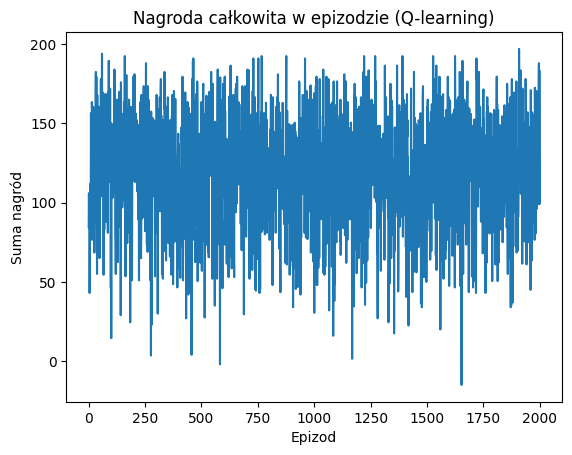



Epizod 100/1200 | reward=118.00 | epsilon=0.606 | buffer=2000
Epizod 200/1200 | reward=103.00 | epsilon=0.367 | buffer=4000
Epizod 300/1200 | reward=43.50 | epsilon=0.222 | buffer=6000
Epizod 400/1200 | reward=109.00 | epsilon=0.135 | buffer=8000
Epizod 500/1200 | reward=105.50 | epsilon=0.082 | buffer=10000
Epizod 600/1200 | reward=77.00 | epsilon=0.050 | buffer=10000
Epizod 700/1200 | reward=119.00 | epsilon=0.050 | buffer=10000
Epizod 800/1200 | reward=84.00 | epsilon=0.050 | buffer=10000
Epizod 900/1200 | reward=175.00 | epsilon=0.050 | buffer=10000
Epizod 1000/1200 | reward=174.00 | epsilon=0.050 | buffer=10000
Epizod 1100/1200 | reward=68.00 | epsilon=0.050 | buffer=10000
Epizod 1200/1200 | reward=152.00 | epsilon=0.050 | buffer=10000


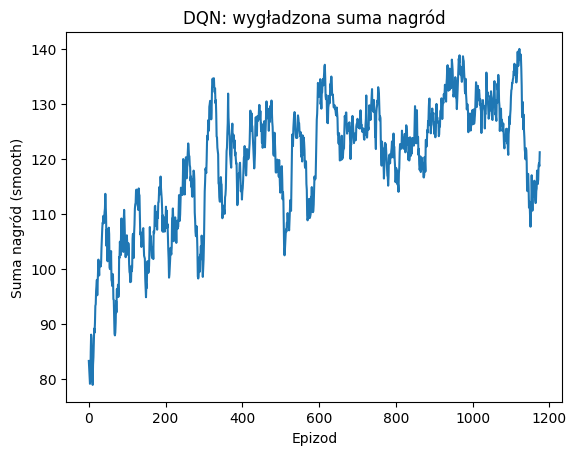

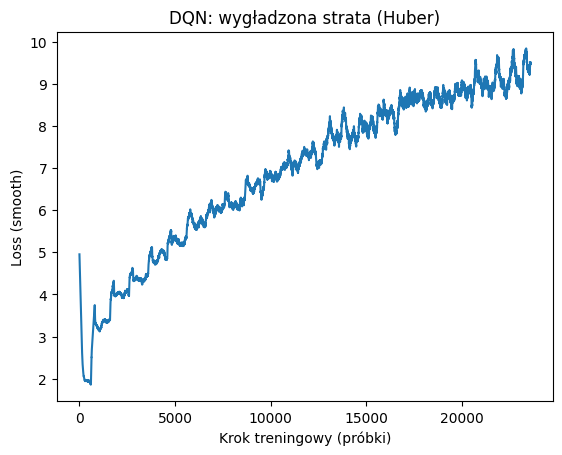

In [1]:
# --- Cell 1 ---
import numpy as np

# --- WARIANT 12: Kontrola glikemii w cukrzycy (MDP) ---
states = ["Normoglycemia", "Hyperglycemia", "SevereHyperglycemia"]
actions = ["NoTreatment", "OralMed", "Insulin"]

S = {name: i for i, name in enumerate(states)}
A = {name: i for i, name in enumerate(actions)}

Q = np.zeros((len(states), len(actions)))

alpha = 0.1
gamma = 0.95
epsilon = 0.2

# P(s'|s,a) z PDF
P = {
    (S["Hyperglycemia"], A["NoTreatment"]): [(S["Hyperglycemia"], 0.70), (S["SevereHyperglycemia"], 0.25), (S["Normoglycemia"], 0.05)],
    (S["Hyperglycemia"], A["OralMed"]):     [(S["Normoglycemia"], 0.40), (S["Hyperglycemia"], 0.50), (S["SevereHyperglycemia"], 0.10)],
    (S["Hyperglycemia"], A["Insulin"]):     [(S["Normoglycemia"], 0.65), (S["Hyperglycemia"], 0.30), (S["SevereHyperglycemia"], 0.05)],

    (S["SevereHyperglycemia"], A["NoTreatment"]): [(S["SevereHyperglycemia"], 0.75), (S["Hyperglycemia"], 0.20), (S["Normoglycemia"], 0.05)],
    (S["SevereHyperglycemia"], A["OralMed"]):     [(S["Hyperglycemia"], 0.60), (S["SevereHyperglycemia"], 0.35), (S["Normoglycemia"], 0.05)],
    (S["SevereHyperglycemia"], A["Insulin"]):     [(S["Hyperglycemia"], 0.50), (S["Normoglycemia"], 0.40), (S["SevereHyperglycemia"], 0.10)],

    (S["Normoglycemia"], A["NoTreatment"]): [(S["Normoglycemia"], 0.85), (S["Hyperglycemia"], 0.14), (S["SevereHyperglycemia"], 0.01)],
    (S["Normoglycemia"], A["OralMed"]):     [(S["Normoglycemia"], 0.88), (S["Hyperglycemia"], 0.12)],
    (S["Normoglycemia"], A["Insulin"]):     [(S["Normoglycemia"], 0.86), (S["Hyperglycemia"], 0.13), (S["SevereHyperglycemia"], 0.01)],
}

action_cost = {
    A["NoTreatment"]: 0.0,
    A["OralMed"]: -1.5,
    A["Insulin"]: -3.0,
}

def choose_action(state):
    if np.random.rand() < epsilon:
        return np.random.randint(len(actions))
    return int(np.argmax(Q[state]))

def sample_next_state(s, a):
    probs = P[(s, a)]
    r = np.random.rand()
    cum = 0.0
    for ns, p in probs:
        cum += p
        if r <= cum:
            return ns
    return probs[-1][0]

def reward_fn(next_state, action):
    bonus = 10.0 if next_state == S["Normoglycemia"] else (-6.0 if next_state == S["SevereHyperglycemia"] else 0.0)
    return bonus + action_cost[action]

def step(state, action):
    next_state = sample_next_state(state, action)
    reward = reward_fn(next_state, action)
    return next_state, reward

for episode in range(500):
    state = S["SevereHyperglycemia"]
    for _ in range(20):
        action = choose_action(state)
        next_state, reward = step(state, action)
        Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])
        state = next_state


# --- Cell 4 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


# --- Cell 6 ---
from dataclasses import dataclass

# --- WARIANT 12: Kontrola glikemii w cukrzycy (MDP) ---
STATES = ["Normoglycemia", "Hyperglycemia", "SevereHyperglycemia"]
ACTIONS = ["NoTreatment", "OralMed", "Insulin"]

S = {name: i for i, name in enumerate(STATES)}
A = {name: i for i, name in enumerate(ACTIONS)}

@dataclass
class StepResult:
    next_state: int
    reward: float
    done: bool

class SimpleMedicalEnv:
    def __init__(self, max_steps=20):
        self.max_steps = max_steps

        # Koszty akcji (odejmowane zawsze)
        self.cost = {
            A["NoTreatment"]: 0.0,
            A["OralMed"]: -1.5,
            A["Insulin"]: -3.0,
        }

        # P(s'|s,a) z PDF (wariant 12)
        self.P = {
            (S["Hyperglycemia"], A["NoTreatment"]): [(S["Hyperglycemia"], 0.70), (S["SevereHyperglycemia"], 0.25), (S["Normoglycemia"], 0.05)],
            (S["Hyperglycemia"], A["OralMed"]):     [(S["Normoglycemia"], 0.40), (S["Hyperglycemia"], 0.50), (S["SevereHyperglycemia"], 0.10)],
            (S["Hyperglycemia"], A["Insulin"]):     [(S["Normoglycemia"], 0.65), (S["Hyperglycemia"], 0.30), (S["SevereHyperglycemia"], 0.05)],

            (S["SevereHyperglycemia"], A["NoTreatment"]): [(S["SevereHyperglycemia"], 0.75), (S["Hyperglycemia"], 0.20), (S["Normoglycemia"], 0.05)],
            (S["SevereHyperglycemia"], A["OralMed"]):     [(S["Hyperglycemia"], 0.60), (S["SevereHyperglycemia"], 0.35), (S["Normoglycemia"], 0.05)],
            (S["SevereHyperglycemia"], A["Insulin"]):     [(S["Hyperglycemia"], 0.50), (S["Normoglycemia"], 0.40), (S["SevereHyperglycemia"], 0.10)],

            (S["Normoglycemia"], A["NoTreatment"]): [(S["Normoglycemia"], 0.85), (S["Hyperglycemia"], 0.14), (S["SevereHyperglycemia"], 0.01)],
            (S["Normoglycemia"], A["OralMed"]):     [(S["Normoglycemia"], 0.88), (S["Hyperglycemia"], 0.12)],
            (S["Normoglycemia"], A["Insulin"]):     [(S["Normoglycemia"], 0.86), (S["Hyperglycemia"], 0.13), (S["SevereHyperglycemia"], 0.01)],
        }

        self.reset()

    def reset(self, start_state="SevereHyperglycemia"):
        self.state = S[start_state]
        self.t = 0
        return self.state

    def _sample_next_state(self, s, a):
        probs = self.P[(s, a)]
        r = np.random.rand()
        cum = 0.0
        for ns, p in probs:
            cum += p
            if r <= cum:
                return ns
        return probs[-1][0]

    def _reward(self, next_state, action):
        # +10 za przejście do N, -6 za przejście do S, w pozostałych przypadkach 0
        if next_state == S["Normoglycemia"]:
            bonus = 10.0
        elif next_state == S["SevereHyperglycemia"]:
            bonus = -6.0
        else:
            bonus = 0.0

        return bonus + self.cost[action]

    def step(self, action):
        self.t += 1
        s = self.state

        next_state = self._sample_next_state(s, action)
        reward = self._reward(next_state, action)

        self.state = next_state
        done = self.t >= self.max_steps
        return StepResult(next_state, reward, done)

env = SimpleMedicalEnv()


# --- Cell 7 ---
state = env.reset()
for i in range(5):
    res = env.step(A["OralMed"])
    print(f"krok {i+1}: {STATES[state]} → {STATES[res.next_state]}, nagroda={res.reward:.2f}")
    state = res.next_state


# --- Cell 9 ---
def epsilon_greedy(Q, s, eps):
    if np.random.rand() < eps:
        return np.random.randint(Q.shape[1])
    return np.argmax(Q[s])

def q_learning(env, episodes=2000, alpha=0.1, gamma=0.95, epsilon=0.3):
    Q = np.zeros((len(STATES), len(ACTIONS)))
    rewards = []

    for ep in range(episodes):
        s = env.reset()
        total = 0
        while True:
            a = epsilon_greedy(Q, s, epsilon)
            res = env.step(a)

            Q[s, a] += alpha * (
                res.reward + gamma * np.max(Q[res.next_state]) - Q[s, a]
            )

            total += res.reward
            s = res.next_state

            if res.done:
                break
        rewards.append(total)

    return Q, rewards

Q, rewards = q_learning(env, episodes=2000, alpha=0.1, gamma=0.95, epsilon=0.3)


# --- Cell 11 ---
policy = {STATES[s]: ACTIONS[np.argmax(Q[s])] for s in range(len(STATES))}
policy


# --- Cell 12 ---
plt.plot(rewards)
plt.title("Nagroda całkowita w epizodzie (Q-learning)")
plt.xlabel("Epizod")
plt.ylabel("Suma nagród")
plt.show()


# --- Cell 14 ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# --- Cell 16 ---
def build_q_network(state_dim, action_dim):
    model = keras.Sequential([
        layers.Input(shape=(state_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(action_dim)
    ])
    return model

def encode_state(s, n_states):
    x = np.zeros(n_states, dtype=np.float32)
    x[s] = 1.0
    return x

def epsilon_greedy_action(model, state_vec, eps, n_actions):
    if np.random.rand() < eps:
        return np.random.randint(n_actions)
    q = model(np.expand_dims(state_vec, 0), training=False).numpy()[0]
    return int(np.argmax(q))


# --- Cell 19 ---
class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.capacity = capacity
        self.data = []
        self.pos = 0

    def push(self, s, a, r, s2, done):
        item = (s, a, r, s2, done)
        if len(self.data) < self.capacity:
            self.data.append(item)
        else:
            self.data[self.pos] = item
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        idx = np.random.choice(len(self.data), size=batch_size, replace=False)
        batch = [self.data[i] for i in idx]
        s, a, r, s2, d = map(np.array, zip(*batch))
        return s.astype(np.float32), a.astype(np.int32), r.astype(np.float32), s2.astype(np.float32), d.astype(np.float32)

    def __len__(self):
        return len(self.data)


# --- Cell 20 ---
def update_target_network(model, target_model):
    target_model.set_weights(model.get_weights())


# --- Cell 22 ---
def dqn_policy_tf(model):
    pol = {}
    for s in range(len(STATES)):
        s_vec = encode_state(s, len(STATES))
        q = model(np.expand_dims(s_vec, 0), training=False).numpy()[0]
        pol[STATES[s]] = ACTIONS[int(np.argmax(q))]
    return pol


# --- Cell 24 ---
def smooth(x, w=25):
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")


# --- Cell 26 ---
def plot_training(rewards, losses):
    plt.figure()
    plt.plot(smooth(rewards, 25))
    plt.title("DQN: wygładzona suma nagród")
    plt.xlabel("Epizod")
    plt.ylabel("Suma nagród (smooth)")
    plt.show()

    plt.figure()
    plt.plot(smooth(losses, 200))
    plt.title("DQN: wygładzona strata (Huber)")
    plt.xlabel("Krok treningowy (próbki)")
    plt.ylabel("Loss (smooth)")
    plt.show()


# --- Cell 28 ---
# Uwaga: TF determinism może się różnić w zależności od środowiska
tf.random.set_seed(42)


# --- Cell 30 ---
# Zakładamy, że masz już zdefiniowane: STATES, ACTIONS, env = SimpleMedicalEnv(...) (wariant 12)
n_states = len(STATES)
n_actions = len(ACTIONS)

env = SimpleMedicalEnv(max_steps=20)

q_model = build_q_network(state_dim=n_states, action_dim=n_actions)
target_model = build_q_network(state_dim=n_states, action_dim=n_actions)
update_target_network(q_model, target_model)

optimizer = keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = keras.losses.Huber()  # stabilniejsza niż MSE

buffer = ReplayBuffer(capacity=10000)

gamma = 0.95
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

batch_size = 64
episodes = 1200
warmup_steps = 200
target_update_freq = 50

episode_rewards = []
loss_history = []

@tf.function
def train_step(states_b, actions_b, rewards_b, next_states_b, dones_b):
    next_q = target_model(next_states_b, training=False)
    max_next_q = tf.reduce_max(next_q, axis=1)
    targets = rewards_b + gamma * max_next_q * (1.0 - dones_b)

    with tf.GradientTape() as tape:
        q_values = q_model(states_b, training=True)
        idx = tf.stack([tf.range(tf.shape(actions_b)[0]), actions_b], axis=1)
        q_sa = tf.gather_nd(q_values, idx)
        loss = loss_fn(targets, q_sa)

    grads = tape.gradient(loss, q_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, q_model.trainable_variables))
    return loss

step_count = 0
for ep in range(episodes):
    s = env.reset(start_state="SevereHyperglycemia")
    s_vec = encode_state(s, n_states)
    total_reward = 0.0

    while True:
        a = epsilon_greedy_action(q_model, s_vec, epsilon, n_actions)
        res = env.step(a)

        s2_vec = encode_state(res.next_state, n_states)
        buffer.push(s_vec, a, res.reward, s2_vec, float(res.done))
        step_count += 1

        s_vec = s2_vec
        total_reward += res.reward

        if step_count > warmup_steps and len(buffer) >= batch_size:
            sb, ab, rb, s2b, db = buffer.sample(batch_size)
            loss = train_step(
                tf.convert_to_tensor(sb),
                tf.convert_to_tensor(ab),
                tf.convert_to_tensor(rb),
                tf.convert_to_tensor(s2b),
                tf.convert_to_tensor(db),
            )
            loss_history.append(float(loss.numpy()))

        if res.done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (ep + 1) % target_update_freq == 0:
        update_target_network(q_model, target_model)

    episode_rewards.append(total_reward)

    if (ep + 1) % 100 == 0:
        print(f"Epizod {ep+1}/{episodes} | reward={total_reward:.2f} | epsilon={epsilon:.3f} | buffer={len(buffer)}")


# --- Cell 32 ---
plot_training(episode_rewards, loss_history)


# --- Cell 34 ---
dqn_policy_tf(q_model)


# --- Cell 40 ---
def explain_action(q_model, state_idx):
    s_vec = encode_state(state_idx, len(STATES))
    q_values = q_model(np.expand_dims(s_vec, 0), training=False).numpy()[0]

    df = pd.DataFrame({
        "akcja": ACTIONS,
        "Q(s,a)": q_values
    }).sort_values("Q(s,a)", ascending=False).reset_index(drop=True)

    return df


# --- Cell 41 ---
state_name = "SevereHyperglycemia"
state_idx = STATES.index(state_name)

explain_action(q_model, state_idx)


# --- Cell 44 ---
def counterfactual_explanation(q_model, state_idx):
    df = explain_action(q_model, state_idx)
    best = df.iloc[0]
    second = df.iloc[1]

    diff = best["Q(s,a)"] - second["Q(s,a)"]

    return {
        "najlepsza_akcja": best["akcja"],
        "alternatywa": second["akcja"],
        "roznica_Q": float(diff)
    }


# --- Cell 45 ---
counterfactual_explanation(q_model, state_idx)


# --- Cell 47 ---
def evaluate_policy_under_cost(insulin_cost):
    env_tmp = SimpleMedicalEnv(max_steps=20)
    env_tmp.cost[A["Insulin"]] = insulin_cost

    q_tmp = build_q_network(n_states, n_actions)
    target_tmp = build_q_network(n_states, n_actions)
    update_target_network(q_tmp, target_tmp)

    buffer_tmp = ReplayBuffer()
    optimizer_tmp = keras.optimizers.Adam(1e-3)

    for _ in range(300):
        s = env_tmp.reset(start_state="SevereHyperglycemia")
        s_vec = encode_state(s, n_states)
        while True:
            a = epsilon_greedy_action(q_tmp, s_vec, 0.2, n_actions)
            res = env_tmp.step(a)
            s2_vec = encode_state(res.next_state, n_states)
            buffer_tmp.push(s_vec, a, res.reward, s2_vec, float(res.done))
            s_vec = s2_vec
            if res.done:
                break

    return dqn_policy_tf(q_tmp)
